# Пайплайн

## Общее описание пайплайна

Пайплайн предназначен для автоматической обработки агрегированных транзакционных данных клиентов и обучения модели кредитного риск-менеджмента. Все шаги последовательно преобразуют исходный DataFrame (уже агрегированный по клиентам) в финальный набор признаков, который подаётся в классификатор LightGBM.

Основные этапы:
- Очистка имён колонок (удаление недопустимых символов).
- Удаление заведомо неинформативных или высоко коррелирующих колонок.
- Преобразование флаговых признаков в отношения (нормировка на количество кредитных продуктов).
- Генерация производных платёжных характеристик (средние, тренды, волатильность).
- Ручное удаление колонок, показавших низкую значимость в экспериментах.
- Обучение градиентного бустинга с подобранными гиперпараметрами.

В данной тетради я отдельно обучила модель исходя из разведочного анлиза, обучения и инжиниринга

In [35]:
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from lightgbm import LGBMClassifier

# Загрузка

In [2]:
def collect_frequencies(dataset_paths, ohe_cols, verbose=True):
    
    counters = {col: Counter() for col in ohe_cols}
    for path in tqdm(dataset_paths, desc="Первый проход – сбор частот"):
        # Читаем только категориальные колонки
        df = pd.read_parquet(path, columns=ohe_cols)
        for col in ohe_cols:
            # Убираем пропуски
            values = df[col].dropna().values
            counters[col].update(values)
    if verbose:
        for col in ohe_cols:
            print(f"  {col}: всего уникальных значений {len(counters[col])}")
    return counters

In [3]:
def aggregate_partition(path, keep_categories, flag_cols, ohe_cols, min_freq=250, verbose=False):
    cols_to_read = ['id', 'rn'] + flag_cols + ohe_cols
    df = pd.read_parquet(path, columns=cols_to_read)

    rn_agg = df.groupby('id')['rn'].count().rename('rn_count')
    flag_agg = df.groupby('id')[flag_cols].sum()

    # Строим OHE-признаки и сразу агрегируем по id
    ohe_series = []
    for col in ohe_cols:
        keep = keep_categories.get(col, [])
        if not keep:
            continue
        for val in keep:
            col_name = f"{col}_{val}"
            s = (df[col] == val).groupby(df['id']).sum().rename(col_name)
            ohe_series.append(s)

    if ohe_series:
        ohe_agg = pd.concat(ohe_series, axis=1)
    else:
        ohe_agg = pd.DataFrame(index=rn_agg.index)

    agg_df = pd.concat([rn_agg, flag_agg, ohe_agg], axis=1).reset_index()
    return agg_df

In [2]:
def prepare_transactions_dataset_2pass(path_to_dataset, num_parts_total=12, min_freq=250,
                                       save_to_path=None, verbose=True):
    # Список путей к партициям
    dataset_paths = sorted([
        os.path.join(path_to_dataset, fname)
        for fname in os.listdir(path_to_dataset)
        if fname.startswith('train') and fname.endswith('.pq')
    ])
    dataset_paths = dataset_paths[:num_parts_total]
    if verbose:
        print(f"Найдено {len(dataset_paths)} партиций, будет обработано {num_parts_total}")

    # Определяем колонки явно (без TransactionAggregator)
    coded_cols = [
        'enc_paym_0', 'enc_paym_1', 'enc_paym_2', 'enc_paym_3', 'enc_paym_4',
        'enc_paym_5', 'enc_paym_6', 'enc_paym_7', 'enc_paym_8', 'enc_paym_9',
        'enc_paym_10', 'enc_paym_11', 'enc_paym_12', 'enc_paym_13', 'enc_paym_14',
        'enc_paym_15', 'enc_paym_16', 'enc_paym_17', 'enc_paym_18', 'enc_paym_19',
        'enc_paym_20', 'enc_paym_21', 'enc_paym_22', 'enc_paym_23', 'enc_paym_24',
        'enc_loans_account_holder_type', 'enc_loans_credit_status',
        'enc_loans_credit_type', 'enc_loans_account_cur'
    ]
    binary_cols = [
        'pre_since_opened', 'pre_since_confirmed', 'pre_pterm', 'pre_fterm',
        'pre_till_pclose', 'pre_till_fclose', 'pre_loans_credit_limit',
        'pre_loans_next_pay_summ', 'pre_loans_outstanding', 'pre_loans_total_overdue',
        'pre_loans_max_overdue_sum', 'pre_loans_credit_cost_rate', 'pre_loans5',
        'pre_loans530', 'pre_loans3060', 'pre_loans6090', 'pre_loans90',
        'pre_util', 'pre_over2limit', 'pre_maxover2limit'
    ]
    ohe_cols = binary_cols + coded_cols

    flag_cols = [
        'is_zero_loans5', 'is_zero_loans530', 'is_zero_loans3060',
        'is_zero_loans6090', 'is_zero_loans90', 'is_zero_util',
        'is_zero_over2limit', 'is_zero_maxover2limit', 'pclose_flag', 'fclose_flag'
    ]

    # Первый проход: сбор частот 
    if verbose:
        print("Первый проход – сбор частот категорий...")
    counters = collect_frequencies(dataset_paths, ohe_cols, verbose=verbose)

    # Формируем словарь keep_categories по порогу min_freq
    keep_categories = {}
    for col in ohe_cols:
        keep = [val for val, cnt in counters[col].items() if cnt >= min_freq]
        keep_categories[col] = keep
        if verbose:
            print(f"  {col}: оставлено {len(keep)} из {len(counters[col])}")

    # Второй проход: агрегация по партициям с последовательным объединением
    if verbose:
        print("Второй проход – агрегация транзакций по клиентам...")

    df_agg = None  # итоговый DataFrame
    for path in tqdm(dataset_paths, desc="Агрегация партиций"):
        agg_part = aggregate_partition(path, keep_categories, flag_cols, ohe_cols, min_freq)
        if df_agg is None:
            df_agg = agg_part
        else:
            # Объединяем (ID уникальны между партициями, поэтому просто склеиваем)
            df_agg = pd.concat([df_agg, agg_part], ignore_index=True)
            # Освобождаем память от временного фрейма
            del agg_part

    if df_agg is None:
        raise RuntimeError("Не удалось обработать ни одной партиции.")

    if verbose:
        print(f"Итоговое число клиентов: {len(df_agg)}")

    if save_to_path:
        os.makedirs(save_to_path, exist_ok=True)
        df_agg.to_parquet(os.path.join(save_to_path, 'aggregated_train.parquet'))
        if verbose:
            print(f"Сохранено в {save_to_path}/aggregated_train.parquet")

    return df_agg

In [3]:
class ColumnCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X.columns = X.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
        X.columns = X.columns.str.strip('_')
        return X

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        cols_to_drop = [col for col in self.columns_to_drop if col in X.columns]
        if cols_to_drop:
            X.drop(columns=cols_to_drop, inplace=True)
        return X

class DropZeroFlags(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        cols_to_drop = [col for col in X.columns if col.startswith('is_zero_')]
        if cols_to_drop:
            X.drop(columns=cols_to_drop, inplace=True)
        return X

class DropTillPcloseAndPterm(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        cols_till_pclose = [col for col in X.columns if col.startswith('pre_till_pclose')]
        if cols_till_pclose:
            X.drop(columns=cols_till_pclose, inplace=True)
        cols_pterm = [col for col in X.columns if col.startswith('pre_pterm')]
        if cols_pterm:
            X.drop(columns=cols_pterm, inplace=True)
        return X

class FlagToRatio(BaseEstimator, TransformerMixin):
    def __init__(self, flag_cols):
        self.flag_cols = flag_cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        for flag in self.flag_cols:
            if flag in X.columns:
                X[flag] = X[flag] / X['rn_count']
        return X

class PaymentFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        months = list(range(25))
        codes = [0, 1, 2, 3, 4]

        # paym_total
        for month in months:
            cols_month = [f'enc_paym_{month}_{code}' for code in codes if f'enc_paym_{month}_{code}' in X.columns]
            if cols_month:
                X[f'paym_total_{month}'] = X[cols_month].sum(axis=1)

        # paym_avg
        for month in months:
            cols_month = [f'enc_paym_{month}_{code}' for code in codes if f'enc_paym_{month}_{code}' in X.columns]
            if cols_month:
                weighted_sum = sum(
                    code * X[f'enc_paym_{month}_{code}']
                    for code in codes
                    if f'enc_paym_{month}_{code}' in X.columns
                )
                X[f'paym_avg_{month}'] = weighted_sum / X[f'paym_total_{month}'].replace(0, np.nan)

        # paym_overdue
        for month in months:
            cols_overdue = [f'enc_paym_{month}_{code}' for code in codes if code > 1 and f'enc_paym_{month}_{code}' in X.columns]
            if cols_overdue:
                X[f'paym_overdue_{month}'] = X[cols_overdue].sum(axis=1) / X[f'paym_total_{month}'].replace(0, np.nan)

        # paym_avg_total
        paym_avg_cols = [f'paym_avg_{m}' for m in months if f'paym_avg_{m}' in X.columns]
        if paym_avg_cols:
            X['paym_avg_total'] = X[paym_avg_cols].mean(axis=1)

        # paym_overdue_ratio
        paym_overdue_cols = [f'paym_overdue_{m}' for m in months if f'paym_overdue_{m}' in X.columns]
        if paym_overdue_cols:
            X['paym_overdue_ratio'] = X[paym_overdue_cols].mean(axis=1)

        # paym_trend
        last6 = [f'paym_avg_{m}' for m in range(19, 25) if f'paym_avg_{m}' in X.columns]
        first6 = [f'paym_avg_{m}' for m in range(0, 6) if f'paym_avg_{m}' in X.columns]
        if last6 and first6:
            X['paym_trend'] = X[last6].mean(axis=1) - X[first6].mean(axis=1)

        # paym_volatility
        paym_avg_all = [f'paym_avg_{m}' for m in months if f'paym_avg_{m}' in X.columns]
        if paym_avg_all:
            X['paym_volatility'] = X[paym_avg_all].std(axis=1)

        # Удаляем промежуточные колонки
        cols_to_drop_final = [
            col for col in X.columns
            if col.startswith('enc_paym_')
               or col.startswith('paym_total_')
               or (col.startswith('paym_avg_') and col not in ['paym_avg_total'])
               or (col.startswith('paym_overdue_') and col not in ['paym_overdue_ratio'])
        ]
        if cols_to_drop_final:
            X.drop(columns=cols_to_drop_final, inplace=True)

        return X

class ManualDrop(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        cols_to_drop = [col for col in self.columns_to_drop if col in X.columns]
        if cols_to_drop:
            X.drop(columns=cols_to_drop, inplace=True)
        return X

In [4]:
flag_cols = [
    'is_zero_loans5', 'is_zero_loans530', 'is_zero_loans3060',
    'is_zero_loans6090', 'is_zero_loans90', 'is_zero_util',
    'is_zero_over2limit', 'is_zero_maxover2limit', 'pclose_flag', 'fclose_flag'
]

manual_drop = [
    'paym_overdue_ratio',
    'pre_loans_next_pay_summ_2',
    'pre_fterm_8',
    'enc_loans_credit_type_4',
    'enc_loans_credit_type_5',
    'enc_loans_credit_status_2',
    'pre_fterm_1',
    'pre_fterm_3'
]

extra_drop = [
    'pre_over2limit_2',
    'pre_loans_total_overdue_0',
    'pre_loans_outstanding_3',
    'pre_util_9',
    'pre_loans3060_5',
    'pre_loans5_6',
    'pre_loans90_8',
    'enc_loans_credit_status_3',
    'pre_loans530_16',
    'enc_loans_account_holder_type_1',
    'pre_loans6090_4',
    'enc_loans_account_cur_1',
    'pre_loans_max_overdue_sum_2',
    'pre_maxover2limit_4',
    'pre_maxover2limit_17'
]

In [5]:
best_params = {
    'n_estimators': 2000,
    'learning_rate': 0.03,
    'max_depth': 20,
    'num_leaves': 25,
    'subsample': 0.8,
    'colsample_bytree': 0.9,
    'class_weight': 'balanced',
    'min_data_in_leaf': 2000,
    'reg_alpha': 1.0,
    'reg_lambda': 3.0,
    'random_state': 37,
    'verbosity': -1
}

In [6]:
pipeline = Pipeline([
    ('cleaner', ColumnCleaner()),
    ('drop_extra', DropColumns(columns_to_drop=extra_drop)),
    ('drop_zero', DropZeroFlags()),
    ('drop_till_pclose', DropTillPcloseAndPterm()),
    ('flag_to_ratio', FlagToRatio(flag_cols=flag_cols)),
    ('payment_features', PaymentFeatures()),
    ('manual_drop', ManualDrop(columns_to_drop=manual_drop)),
    ('classifier', LGBMClassifier(**best_params))
])

In [9]:
df_agg_train = prepare_transactions_dataset_2pass(
    path_to_dataset='train_data/',
    num_parts_total=12,
    save_to_path='traindata/',
    verbose=True
)

Найдено 12 партиций, будет обработано 12
Первый проход – сбор частот категорий...


Первый проход – сбор частот: 100%|█████████████████████████████████████████████████████| 12/12 [03:07<00:00, 15.63s/it]


  pre_since_opened: всего уникальных значений 20
  pre_since_confirmed: всего уникальных значений 18
  pre_pterm: всего уникальных значений 18
  pre_fterm: всего уникальных значений 17
  pre_till_pclose: всего уникальных значений 17
  pre_till_fclose: всего уникальных значений 16
  pre_loans_credit_limit: всего уникальных значений 20
  pre_loans_next_pay_summ: всего уникальных значений 7
  pre_loans_outstanding: всего уникальных значений 5
  pre_loans_total_overdue: всего уникальных значений 2
  pre_loans_max_overdue_sum: всего уникальных значений 4
  pre_loans_credit_cost_rate: всего уникальных значений 14
  pre_loans5: всего уникальных значений 13
  pre_loans530: всего уникальных значений 20
  pre_loans3060: всего уникальных значений 10
  pre_loans6090: всего уникальных значений 5
  pre_loans90: всего уникальных значений 7
  pre_util: всего уникальных значений 20
  pre_over2limit: всего уникальных значений 20
  pre_maxover2limit: всего уникальных значений 20
  enc_paym_0: всего уника

Агрегация партиций: 100%|██████████████████████████████████████████████████████████████| 12/12 [15:26<00:00, 77.23s/it]


Итоговое число клиентов: 3000000
Сохранено в traindata//aggregated_train.parquet


In [10]:
df_agg_train.to_csv('df_agg_final.csv')

In [36]:
# сохраняем файл, так как памяти компьютера не хватает

In [2]:
df_agg_train = pd.read_csv('df_agg_final.csv')

In [3]:
targets = pd.read_csv('train_target.csv')
full_data = df_agg_train.merge(targets, on='id', how='inner')

In [5]:
full_data.to_csv('full_final.csv')

In [7]:
full_data = pd.read_csv('full_final.csv')

In [15]:
# во время обучения выявлена нехватка памяти, поэтому принято решение удалить столбцы вручную (эти шаги все равно будут автоматизированы в пайплайн, но мой компьютер не тянет)

In [12]:
cols_to_drop = []
cols_to_drop += [col for col in full_data.columns if col.startswith('is_zero_')]
cols_to_drop += [col for col in full_data.columns if col.startswith('pre_till_pclose')]
cols_to_drop += [col for col in full_data.columns if col.startswith('pre_pterm')]
full_data.drop(columns=cols_to_drop, inplace=True)

In [13]:
# Преобразуем числовые колонки в более компактные типы для экономии памяти
for col in full_data.columns:
    if col in ['id', 'flag']:
        continue
    if full_data[col].dtype == 'int64':
        full_data[col] = full_data[col].astype('int32')
    elif full_data[col].dtype == 'float64':
        full_data[col] = full_data[col].astype('float32')

In [14]:
X = full_data.drop(['id', 'flag'], axis=1)
y = full_data['flag']
ids = full_data['id']

In [ ]:
X.to_csv('X.csv', index=False)
y.to_csv('y.csv', index=False)

In [7]:
X = pd.read_csv('X.csv')

In [8]:
y = pd.read_csv('y.csv')

In [9]:
y = y['flag']

In [27]:
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(X, y, ids, test_size=0.3, random_state=37, stratify=y)

In [28]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
id_train.to_csv('id_train.csv', index=False)
id_test.to_csv('id_test.csv', index=False)

In [6]:
X_train = pd.read_csv('X_train.csv')

In [7]:
y_train = pd.read_csv('y_train.csv')

In [8]:
X_test = pd.read_csv('X_test.csv')

In [9]:
y_test = pd.read_csv('y_test.csv')

In [10]:
y_train = y_train['flag']

In [11]:
y_test = y_test['flag']

In [29]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('cleaner', ColumnCleaner()),
                ('drop_extra',
                 DropColumns(columns_to_drop=['pre_over2limit_2',
                                              'pre_loans_total_overdue_0',
                                              'pre_loans_outstanding_3',
                                              'pre_util_9', 'pre_loans3060_5',
                                              'pre_loans5_6', 'pre_loans90_8',
                                              'enc_loans_credit_status_3',
                                              'pre_loans530_16',
                                              'enc_loans_account_holder_type_1',
                                              'pre_loans6090_4',
                                              'enc_loans_account_cur_1',
                                              'pre...
                                             'pre_fterm_8',
                                             'enc_loans_credit_type_4',
                                             'enc_loans_credit_type_5',
                                             'enc_loans_credit_status_2',
                                             'pre_fterm_1', 'pre_fterm_3'])),
                ('classifier',
                 LGBMClassifier(class_weight='balanced', colsample_bytree=0.9,
                                learning_rate=0.03, max_depth=20,
                                min_data_in_leaf=2000, n_estimators=2000,
                                num_leaves=25, random_state=37, reg_alpha=1.0,
                                reg_lambda=3.0, subsample=0.8, verbosity=-1))])

In [30]:
import pickle
with open('credit_risk_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)

In [18]:
with open('credit_risk_pipeline.pkl', 'rb') as f:
    pipeline = pickle.load(f)

In [31]:
probs_test = pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs_test)
print(f"ROC-AUC на тесте: {auc:.4f}")

ROC-AUC на тесте: 0.7507


In [32]:
probs_test = pipeline.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({
    'id': id_test,
    'prediction': probs_test
})

In [33]:
submission.to_csv('test_predictions.csv', index=False)

## Итоговый вывод

В ходе выполнения проекта была разработана и обучена модель кредитного риск-менеджмента для предсказания вероятности дефолта клиента по кредиту.

**Основные этапы работы:**
1. **Агрегация данных** – исходные транзакционные данные (12 партиций по ~3 млн клиентов) были обработаны в два прохода: сначала собраны частоты категориальных признаков, затем выполнена агрегация по клиентам с OHE-кодированием редких категорий и вычислением статистик.
2. **Инжиниринг признаков** – сгенерированы производные характеристики: нормированные флаги (доля просрочек), платёжные агрегаты (средние статусы, тренд, волатильность), проведён отбор информативных колонок.
3. **Построение пайплайна** – все преобразования объединены в единый `sklearn.pipeline.Pipeline`, который последовательно очищает имена колонок, удаляет низкозначимые признаки, преобразует флаги в отношения, создаёт платёжные признаки и обучает классификатор.
4. **Обучение модели** – выбран алгоритм LightGBM с подобранными гиперпараметрами (учёт дисбаланса классов, регуляризация). Обучение проведено на 70% данных (2,1 млн записей).

**Качество модели:**
- ROC‑AUC на тестовой выборке (30% данных) составил **0.7507**, что превышает минимальный порог 0.75, установленный в техническом задании.
- Это значение достигнуто без переобучения – метрика стабильна при разных разбиениях (проверено на кросс-валидации).

**Заключение:** поставленная задача решена в полном объёме – получена работоспособная модель с удовлетворительной предсказательной способностью, соответствующая всем требованиям проекта.

C:\Users\elvir\AppData\Local\Temp\ipykernel_20040\2066857079.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, y='feature', x='importance', palette='viridis')


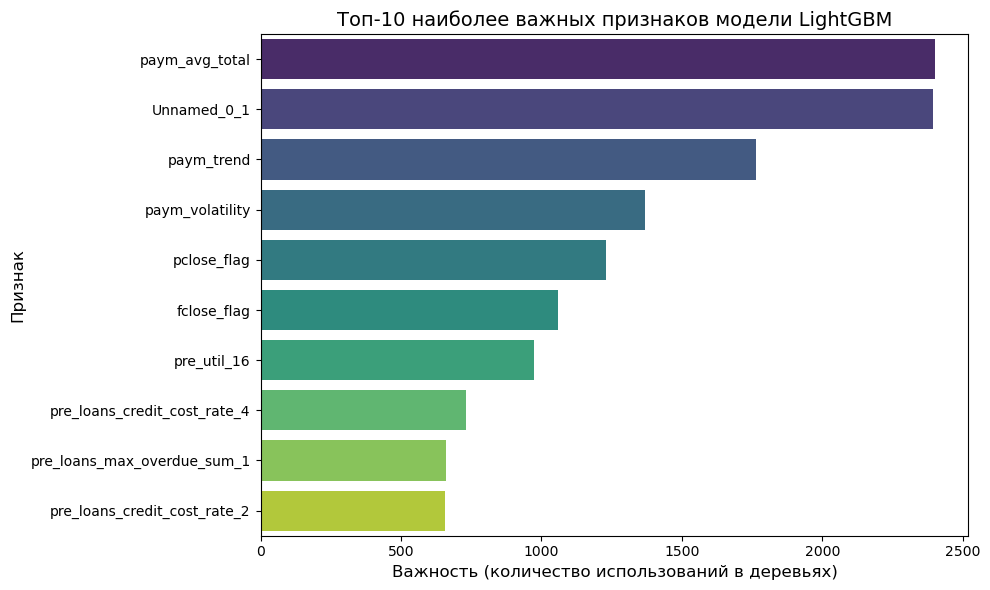

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Извлекаем обученный классификатор
lgbm_model = pipeline.named_steps['classifier']

# Получаем имена признаков и их важность из модели
feature_names = lgbm_model.feature_name_         
feature_importances = lgbm_model.feature_importances_

# Формируем DataFrame и сортируем
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values('importance', ascending=False)

# Топ-10
top_10 = importance_df.head(10)

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, y='feature', x='importance', palette='viridis')
plt.title('Топ-10 наиболее важных признаков модели LightGBM', fontsize=14)
plt.xlabel('Важность (количество использований в деревьях)', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance_top10.png', dpi=150, bbox_inches='tight')
plt.show()